In [1]:
import sys
sys.path.append('../functions')
import numpy as np
#import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
#import torch
import pandas as pd
import multiprocessing
import time
from sklearn.model_selection import ParameterGrid
import linear_sim_func  

In [3]:
!python3 ../functions/main_linear.py

Runtime of the program is 0.10036563873291016 seconds


# One simulation 

In [6]:
n_sim = 500
N_v = [30]
N_test_v = [500]
p_v = [50]
error_sd_v = [1]
L_v = [0.9]
level_v = [0.2]
use_true_contour_v = [True]
n_boot_v = [1000]
ridge_penal_v = [[1,0.5,1e-1, 1e-2, 1e-3, 1e-4]]
#ridge_penal_v = [None]
MC_v = [False]
smoothed_v = [False]
residual_boot_v = [False]
CV_boot_v = [True]
center_G_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,
              'ridge_penal':ridge_penal_v, 'MC':MC_v, 'smoothed':smoothed_v, 'residual_boot':residual_boot_v, 'CV_boot':CV_boot_v, 'center_G':center_G_v}
param_grid = ParameterGrid(param_grid)
for param in param_grid:
    linear_sim_func.sim_linear(param['N'], param['N_test'], param['p'], param['error_sd'], \
                      param['L'],param['level'],param['use_true_contour'], param['n_boot'], 
                        param['ridge_penal'], param['MC'], param['smoothed'], param['residual_boot'], param['CV_boot'], param['center_G'])

In [26]:
mae

0.610364083223544

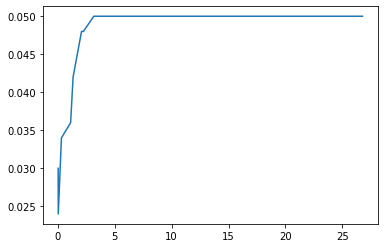

0.9500000000000028
0.974
True
0.752
0.9500000000000028
0.974
0.982
2


In [10]:
from matplotlib import pyplot as plt
x = [z[0] for z in range_v]
y = [z[1] for z in range_v]
plt.plot(x,y)
plt.show()
print(L)
print(U)
print(contain)
print(L1)
print(L2)
print(U1)
print(U2)
print(n_points)

# Multiple simulations (only works for MacOS)

In [4]:
from datetime import date
today = date.today()
date = today.strftime("%d%m%Y")
file_name = 'sim_results_boot_2000'+date+'.csv'
df_total = pd.DataFrame()
n_sim = 2
N_v = [50]
N_test_v = [500]
p_v = [160]
error_sd_v = [1]
L_v = [0.95]
level_v = [0.2]
use_true_contour_v = [False]
n_boot_v = [2000]
ridge_v = [True]
df_result = []
param_grid = {'N': N_v, 'N_test': N_test_v, 'p': p_v , 'error_sd': error_sd_v, 'L': L_v,
              'level': level_v,  'use_true_contour': use_true_contour_v, 'n_boot':n_boot_v,'ridge':ridge_v}
param_grid = ParameterGrid(param_grid)
start = time.time()
for param in param_grid:
    df = pd.DataFrame(param, index = [0])
    para_df = pd.DataFrame(np.repeat(df.values,n_sim, axis=0))
    para_df.columns = df.columns
    pool_obj = multiprocessing.Pool()
    cur_para = (n_sim*((param['N'], param['N_test'], param['p'], param['error_sd'], \
                      param['L'],param['level'],param['use_true_contour'], param['n_boot'], param['ridge']),))
    df_result.append(np.array(pool_obj.starmap(linear_sim_func.safe_sim_linear,cur_para)))
    pool_obj.close()
    pool_obj.join()
    df_ = pd.DataFrame(np.concatenate(df_result, axis = 0), 
                 columns = ["contain","contain_scb","contain_CS_scb","Lower_bound",
                            "Upper_bound", "L1", "L2", "U1", "U2", "points_in_e1", 
                            "pre_mae", 'inner_points_num', 'outer_points_num' ,'true_set_points_num'])
    df_ = pd.concat([para_df, df_], axis = 1)
    df_total = pd.concat([df_total,df_])
    df_total.to_csv(file_name, index = False)
end = time.time()
print('Runtime of the program is ' + str(end -start) + ' seconds')

ValueError: Shape of passed values is (2, 15), indices imply (2, 14)

In [ ]:
df_total[df_total.use_true_contour==0].mean()

# Using scripts to run (for Windows Ubuntun)

In [28]:
!python3 main.py

Runtime of the program is 281.3313100337982 seconds


# Bootstrap quantile vs True quantile

In [501]:
import bootstrap_func
from linear_sim_func import *
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
# bootstrap
N_test = 500
p = 50
beta =None
error_sd = 1
X_test = None
n_boot = 2000
smoothed = False
residual_boot = False
sparsity = 0
#bias_correction = True
if beta is None:
    rng = np.random.default_rng(None)
    beta = rng.standard_normal(size = p)
    if sparsity > 0:
        index_zero = rng.choice(range(p), size= int(p*sparsity))
        beta[index_zero] = 0
y,X, X_test, mean_test_true = generate_linear_data(N = 100, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
penal_sizes = [2,1,0.5,1e-1, 1e-2, 1e-3, 1e-4]

In [524]:
N = 10
ridge_penal = None
CV_boot = True

In [525]:
y,X, _, _ = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
if ridge_penal is not None:
    mean, se, mean_boot_l = bootstrap_func.fit_bootstrap_ridge(y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot,  penal_sizes = penal_sizes, 
                                                               smoothed = smoothed, residual_boot = residual_boot, CV_boot = CV_boot)
    #mean_linear = linear_fit_predict()
else:# linear model without penality
    mean, se, mean_boot_l = bootstrap_func.fit_bootstrap( y = y, 
                                          X = X, X_test = X_test, n_boot = n_boot, smoothed = smoothed, residual_boot =  residual_boot)

mean_bias_cor = 2*mean - np.mean(mean_boot_l, axis = 0)
# MCMC    
mean_MC_l = []
for i in range(n_boot):
    y_new,X_new, X_test_trash, mean_test_true_trash = generate_linear_data(N = N, N_test = N_test, p = p,beta = beta, error_sd = error_sd, X_test = X_test)
    if ridge_penal is not None:
        if CV_boot:
            clf = RidgeCV(alphas = penal_sizes, store_cv_values = True).fit(X_new, y_new)
            mean_MC_l.append(clf.predict(X_test))
        else:
            mean_MC_l.append(ridge_linear_fit_predict(y_new, X_new, X_test, ridge_penal) )
    else:# linear model without penality
        mean_MC_l.append(linear_fit_predict(y_new, X_new, X_test) )
mean_MC_l = np.array(mean_MC_l)
se_MC = np.std(mean_MC_l, axis = 0)
if smoothed:
    mean_MC = np.mean(mean_MC_l, axis = 0)
else:
    mean_MC = ridge_linear_fit_predict(y, X, X_test, ridge_penal) if ridge_penal is not None else linear_fit_predict(y, X, X_test) 

In [526]:
fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,11,21,51):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i], color = 'red', alpha=0.5, label = 'Monte')
    axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
fig.savefig('../results/'+title+'.png')


fig, axs = plt.subplots(2, 2, sharex = False, sharey = True)
j = 0
for i in (1,100,200,300):
    if j==0:
        q1, q2 = 0,0
    elif j==1:
        q1,q2 =1,0
    elif j==2:
        q1,q2 = 0,1
    else:
        q1,q2 = 1,1
    axs[q1,q2].hist(mean_boot_l[:,i]/se[i], color = 'green', alpha=0.5, label = 'bootstrap')
    axs[q1,q2].hist(mean_MC_l[:,i]/se_MC[i], color = 'red', alpha=0.5, label = 'Monte')
    # axs[q1,q2].axvline(mean[i], color='green', linestyle='dashed', linewidth=1)
    # #plt.axvline(mean_bias_cor[i], color='green', linestyle='dashed', linewidth=1)
    # axs[q1,q2].axvline(mean_test_true[i], color='red', linestyle='dashed', linewidth=1)
    axs[q1,q2].set_title(' Subject='+str(i))
    if j==0:
        axs[q1,q2].legend(loc="upper left")
    print(np.std(mean_boot_l[:,i]))
    print(np.std(mean_MC_l[:,i]))
    print(np.quantile(mean_boot_l[:,i], q = 0.95))
    print(np.quantile(mean_MC_l[:,i], q = 0.95))
    j += 1
title = 'p='+str(p)+'; n='+str(N)+'; Model='+'linear' if ridge_penal is None else 'p='+str(p)+'; n='+str(N)+' Model='+'Ridge'
title = title+'; sparsity='+str(sparsity)+'; standardized'
fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.suptitle(title)
fig.show()
fig.savefig('../results/'+title+'.png')

# G = (mean_boot_l-np.mean(mean_boot_l,axis = 0))/se
# #np.mean(mean_boot_l,axis = 0)
# G_MC = (mean_MC_l-mean_test_true)/se_MC
# plt.hist(G[:,i], color = 'yellow', alpha=0.5)
# plt.hist(G_MC[:,i], color = 'red', alpha=0.5)
# plt.show()
# print(np.std(G[:,i]))
# print(np.std(G_MC[:,i]))
# print(np.quantile(G[:,i], q = 0.95))
# print(np.quantile(G_MC[:,i], q = 0.95))
# print(np.quantile(G[:,i], q = 0.1))
# print(np.quantile(G_MC[:,i], q = 0.1))
# print(np.quantile(np.abs(G[:,i]), q = 0.95))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.95))
# print(np.quantile(np.abs(G[:,i]), q = 0.1))
# print(np.quantile(np.abs(G_MC[:,i]), q = 0.1))

1.2303823531323501
3.2021939271631
3.477707303652293
6.811853633398072
2.0546337794300533
3.337491299569834
2.1568803046609473
2.96672294195106
1.6971365836330732
3.1110525173491994
3.404648432198335
3.818951871319404
2.452859416959044
2.958373721472482
2.765648437668953
4.262298833639071
1.2303823531323501
3.2021939271631
3.477707303652293
6.811853633398072
1.5105734017046395
2.7778374254665548
2.958618912516504
3.428560823746828
2.087192596903773
2.921012865518266
4.045958206054438
4.987048418997744
1.5073333795404738
2.744734471146809
2.5445995234432073
4.524327375514144


/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:30: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
/Users/juntingren/opt/anaconda3/envs/deeplearning/lib/python3.7/site-packages/ipykernel_launcher.py:63: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


In [442]:
print(np.mean(np.std(mean_boot_l, axis = 0) > np.std(mean_MC_l, axis = 0)))
print(np.mean(np.abs((np.std(mean_boot_l, axis = 0) - np.std(mean_MC_l, axis = 0)))))

0.02
0.7761519549930384


In [74]:
mean[16]

-19.21632190769464

In [432]:
np.mean(mean_boot_l, axis = 0)[16]

9.672344929039511

In [424]:
np.mean(mean_boot_l[:,i])

-6.330184772354789